# Packages Utilisé

In [3]:
#! pip install pandas -q
#! pip install matplotlib -q
#! pip install cartiflette -q
import pandas as pd
import matplotlib.pyplot as plt


# Données du projet

In [18]:
df = pd.read_csv(
'https://www.data.gouv.fr/fr/datasets/r/182268fc-2103-4bcb-a850-6cf90b02a9eb'  
)
df.head()

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_25204\4263583973.py:1: DtypeWarning: Columns (4) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(


,code_departement,libelle_departement,code_commune,libelle_commune,prenom,nom,voix
0,01,Ain,1,L'Abergement-Clémenciat,Nathalie,ARTHAUD,3
1,01,Ain,2,L'Abergement-de-Varey,Nathalie,ARTHAUD,2
2,01,Ain,4,Ambérieu-en-Bugey,Nathalie,ARTHAUD,38
3,01,Ain,5,Ambérieux-en-Dombes,Nathalie,ARTHAUD,8
4,01,Ain,6,Ambléon,Nathalie,ARTHAUD,0


## Question 1

In [19]:
# code_commune : on concatène le code département (2 chiffres) et le code commune (3 chiffres)
df['code_commune'] = (
    df['code_departement'].astype(str).str.zfill(2)
    + df['code_commune'].astype(str).str.zfill(3)
)

# candidat : prénom + nom
df['candidat'] = df['prenom'].astype(str) + ' ' + df['nom'].astype(str)

# Vérification : Montrouge doit être 92049
assert '92049' in df['code_commune'].values, "Montrouge (92049) introuvable !"
print("code_commune correct – exemple Montrouge :", df[df['code_commune'] == '92049']['libelle_commune'].iloc[0])

df[['code_commune', 'libelle_commune', 'candidat', 'voix']].head()

code_commune correct – exemple Montrouge : Montrouge


,code_commune,libelle_commune,candidat,voix
0,01001,L'Abergement-Clémenciat,Nathalie ARTHAUD,3
1,01002,L'Abergement-de-Varey,Nathalie ARTHAUD,2
2,01004,Ambérieu-en-Bugey,Nathalie ARTHAUD,38
3,01005,Ambérieux-en-Dombes,Nathalie ARTHAUD,8
4,01006,Ambléon,Nathalie ARTHAUD,0


## Question 2


In [21]:
# Exclusion des lignes non-candidats (abstentions, blancs, nuls)
# On identifie les votes non exprimés : ils ont généralement un nom spécifique
non_candidats = ['ABSTENTION', 'BLANC', 'NUL', 'EXPRIME']
masque_candidats = ~df['nom'].str.upper().isin(non_candidats)

candidats = df[masque_candidats]['candidat'].nunique()

print(f"En 2022, il y avait {candidats} candidats à l'élection présidentielle.")

En 2022, il y avait 15 candidats à l'élection présidentielle.


## Question 3: Comparaison des scores départements aux moyennes nationales

In [22]:
# Votes exprimés uniquement (on exclut les non-candidats)
df_candidats = df[masque_candidats].copy()

# Scores nationaux
total_exprime = df_candidats['voix'].sum()

score_national = (
    df_candidats
    .groupby('candidat', as_index=False)['voix']
    .sum()
    .rename(columns={'voix': 'votes_national'})
    .sort_values('votes_national', ascending=False)
    .reset_index(drop=True)
)

score_national['score_national'] = score_national['votes_national'] / total_exprime * 100

# Affichage propre
display_df = score_national.copy()
display_df['votes_national'] = display_df['votes_national'].apply(lambda x: f"{x:,.0f}".replace(',', ' '))
display_df['score_national'] = display_df['score_national'].apply(lambda x: f"{x:.2f}%")
display_df.index += 1  # classement à partir de 1

print("\n Résultats du 1er tour – 10 avril 2022\n")
display_df


 Résultats du 1er tour – 10 avril 2022



,candidat,votes_national,score_national
1,nan abstentions,12 824 169,26.31%
2,Emmanuel MACRON,9 783 058,20.07%
3,Marine LE PEN,8 133 828,16.69%
4,Jean-Luc MÉLENCHON,7 712 520,15.82%
5,Éric ZEMMOUR,2 485 226,5.10%
6,Valérie PÉCRESSE,1 679 001,3.44%
7,Yannick JADOT,1 627 853,3.34%
8,Jean LASSALLE,1 101 387,2.26%
9,Fabien ROUSSEL,802 422,1.65%
10,Nicolas DUPONT-AIGNAN,725 176,1.49%


###  Question 4 – Scores par département

In [23]:
# Votes par département et par candidat
votes_dep = (
    df_candidats
    .groupby(['code_departement', 'candidat'], as_index=False)['voix']
    .sum()
    .rename(columns={'voix': 'votes_departement'})
)

# Total des votes exprimés par département
total_dep = (
    df_candidats
    .groupby('code_departement')['voix']
    .sum()
    .reset_index()
    .rename(columns={'voix': 'total_dep'})
)

score_departements = votes_dep.merge(total_dep, on='code_departement')
score_departements['score_departement'] = score_departements['votes_departement'] / score_departements['total_dep'] * 100
score_departements = score_departements.drop(columns='total_dep')
score_departements = score_departements.sort_values(['code_departement', 'votes_departement'], ascending=[True, False])

# Vérification pour l'Aude (11)
print(" Vérification pour le département 11 (Aude) :")
aude = score_departements[score_departements['code_departement'] == '11'].copy()
aude['score_departement'] = aude['score_departement'].apply(lambda x: f"{x:.2f}%")
aude

 Vérification pour le département 11 (Aude) :


,code_departement,candidat,votes_departement,score_departement
155,11,Marine LE PEN,64027,22.87%
161,11,nan abstentions,62972,22.50%
151,11,Emmanuel MACRON,43104,15.40%
154,11,Jean-Luc MÉLENCHON,42039,15.02%
164,11,Éric ZEMMOUR,18434,6.59%
153,11,Jean LASSALLE,12382,4.42%
159,11,Valérie PÉCRESSE,7350,2.63%
160,11,Yannick JADOT,6322,2.26%
150,11,Anne HIDALGO,6166,2.20%
152,11,Fabien ROUSSEL,5622,2.01%


###  Question 5 – Jointure avec le niveau national

In [24]:
score_departements = score_departements.merge(
    score_national[['candidat', 'votes_national', 'score_national']],
    on='candidat'
)

# Vérification pour l'Aude
print(" Vérification pour le département 11 (Aude) – 3 premiers candidats :")
check = score_departements[score_departements['code_departement'] == '11'].head(3).copy()
check['score_departement'] = check['score_departement'].apply(lambda x: f"{x:.2f}%")
check['score_national'] = check['score_national'].apply(lambda x: f"{x:.2f}%")
check

 Vérification pour le département 11 (Aude) – 3 premiers candidats :


,code_departement,candidat,votes_departement,score_departement,votes_national,score_national
150,11,Marine LE PEN,64027,22.87%,8133828,16.69%
151,11,nan abstentions,62972,22.50%,12824169,26.31%
152,11,Emmanuel MACRON,43104,15.40%,9783058,20.07%


###  Question 6 – Variable `surrepresentation`

In [25]:
# surrepresentation = (score_dep - score_national) / score_national * 100
score_departements['surrepresentation'] = (
    (score_departements['score_departement'] - score_departements['score_national'])
    / score_departements['score_national']
    * 100
)


print("Exemple (dept 11, Marine Le Pen) :",
      round(score_departements[
          (score_departements['code_departement'] == '11') &
          (score_departements['candidat'] == 'Marine LE PEN')
      ]['surrepresentation'].values[0], 2), "%")

score_departements.head()

Exemple (dept 11, Marine Le Pen) : 37.08 %


,code_departement,candidat,votes_departement,score_departement,votes_national,score_national,surrepresentation
0,01,nan abstentions,97541,22.264094,12824169,26.307134,-15.368606
1,01,Emmanuel MACRON,92206,21.046361,9783058,20.068686,4.871644
2,01,Marine LE PEN,86755,19.802150,8133828,16.685502,18.678774
3,01,Jean-Luc MÉLENCHON,57832,13.200368,7712520,15.821243,-16.565545
4,01,Éric ZEMMOUR,27530,6.283824,2485226,5.098122,23.257639


###  Question 7 – Visualisation des surreprésentations

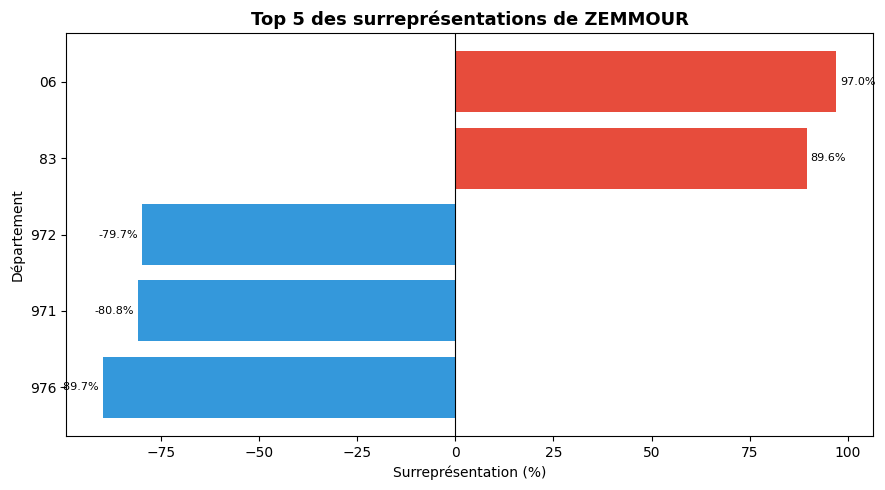

In [26]:
def plot_surrepresentation(candidat_nom, score_departements, top_n=10):
    
    data = score_departements[score_departements['candidat'] == candidat_nom].copy()
    
    if data.empty:
        print(f"Candidat '{candidat_nom}' introuvable.")
        return
    
    # Top N en valeur absolue
    top = (
        data.reindex(data['surrepresentation'].abs().sort_values(ascending=False).index)
        .head(top_n)
        .sort_values('surrepresentation')
    )
    
    nom_court = candidat_nom.split()[-1]  
    
    fig, ax = plt.subplots(figsize=(9, 5))
    colors = ['#e74c3c' if v >= 0 else '#3498db' for v in top['surrepresentation']]
    
    ax.barh(top['code_departement'].astype(str), top['surrepresentation'], color=colors)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_xlabel('Surreprésentation (%)')
    ax.set_ylabel('Département')
    ax.set_title(f'Top {top_n} des surreprésentations de {nom_court}', fontsize=13, fontweight='bold')
    
    # Annotations valeurs
    for i, (val, dep) in enumerate(zip(top['surrepresentation'], top['code_departement'])):
        ha = 'left' if val >= 0 else 'right'
        offset = 1 if val >= 0 else -1
        ax.text(val + offset, i, f"{val:.1f}%", va='center', ha=ha, fontsize=8)
    
    plt.tight_layout()
    plt.show()


# Test sur Éric Zemmour
plot_surrepresentation('Éric ZEMMOUR', score_departements, top_n=5)

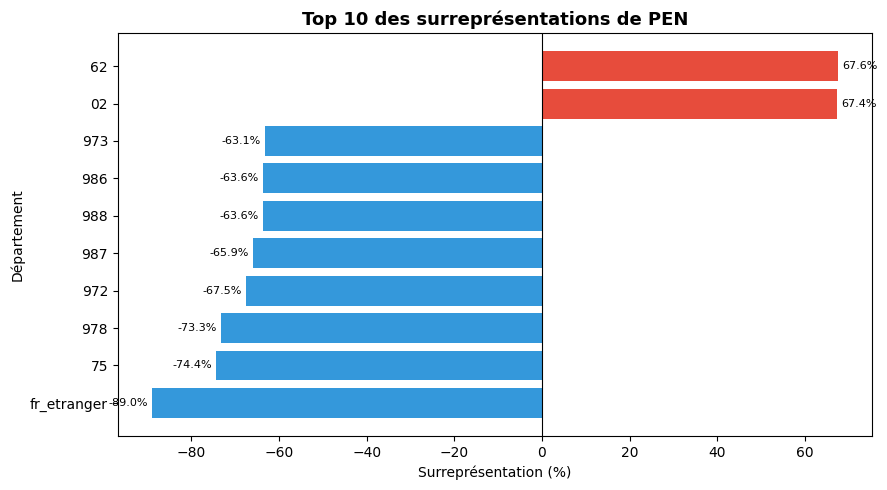

In [27]:
# Test sur Marine Le Pen
plot_surrepresentation('Marine LE PEN', score_departements, top_n=10)

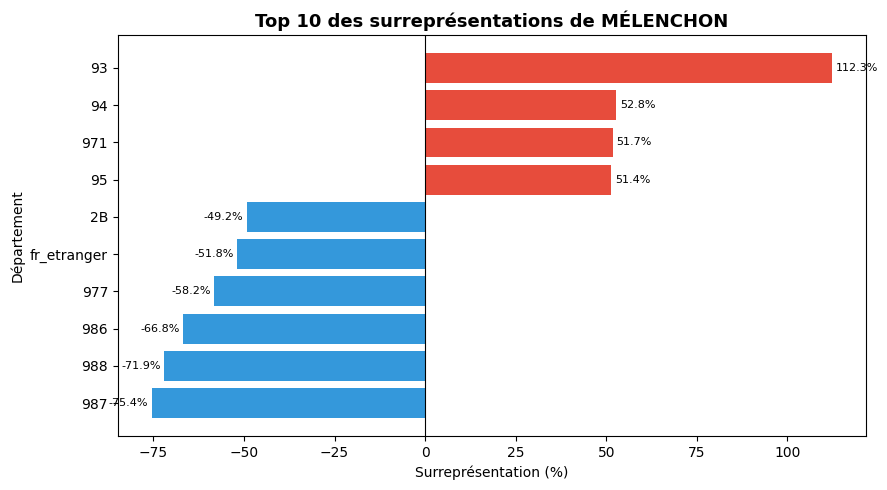

In [28]:
# Test sur Jean-Luc Mélenchon
plot_surrepresentation('Jean-Luc MÉLENCHON', score_departements, top_n=10)

## 3. Cartographie

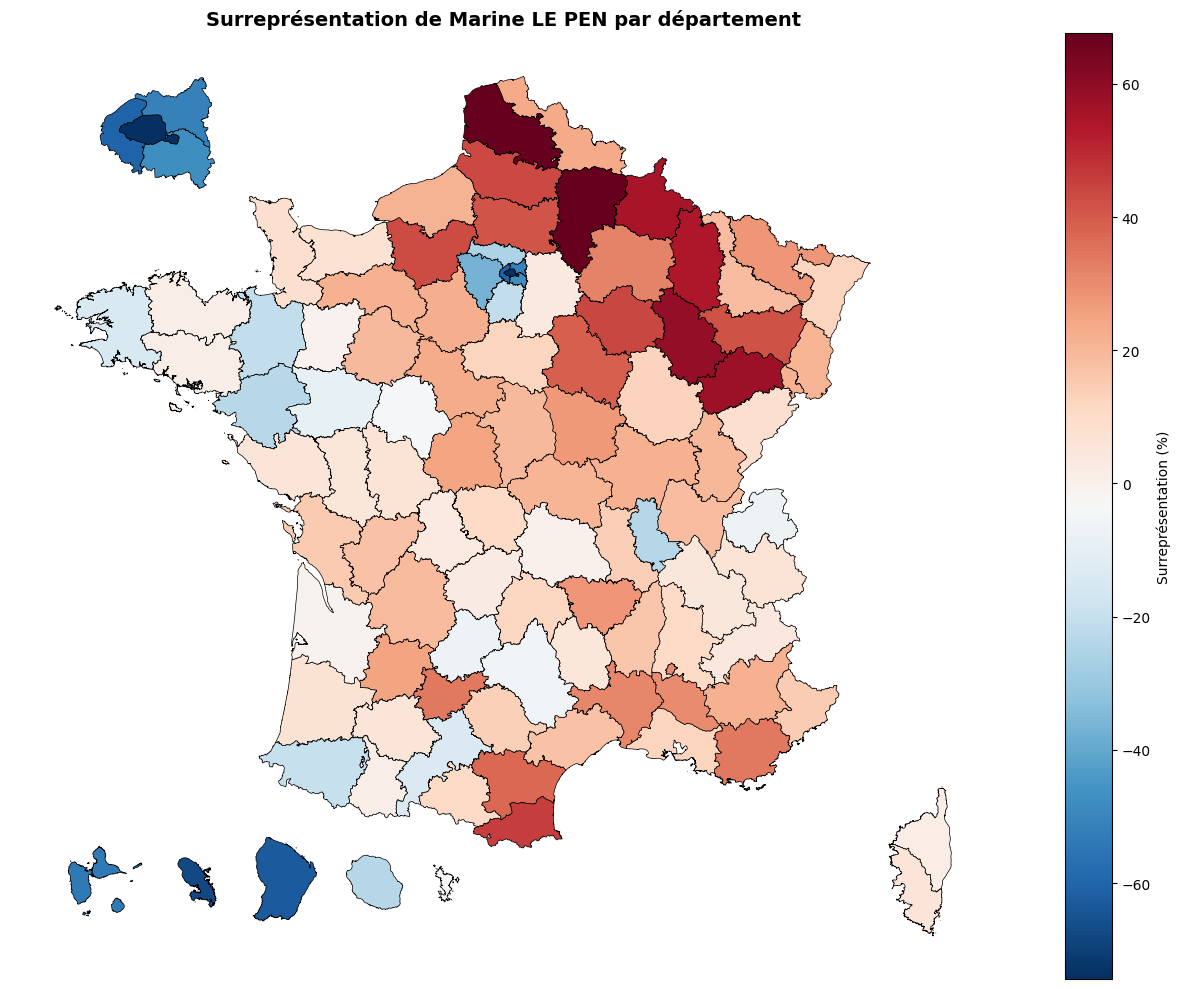

In [ ]:
from cartiflette import carti_download
import geopandas as gpd

# La Fonction suivante permet de restreindre le score_departements par candidat
def get_candidate_data(candidat_nom, score_departements):
    """
    Restreint les données score_departements pour un candidat spécifique.
    
    Paramètress:
    - candidat_nom: nom du candidat
    - score_departements: dataframe avec tous les scores
    
    Returns:
    - dataframe filtrée pour le candidat
    """
    return score_departements[score_departements['candidat'] == candidat_nom].copy()


# Test sur Marine Le Pen
marine_data = get_candidate_data('Marine LE PEN', score_departements)

# Télécharger le fond de carte
departement_borders = carti_download(
    values=["France"],
    crs=4326,
    borders="DEPARTEMENT",
    vectorfile_format="geojson",
    simplification=50,
    filter_by="FRANCE_ENTIERE_DROM_RAPPROCHES",
    source="EXPRESS-COG-CARTO-TERRITOIRE",
    year=2022
)

# Jointure avec le fond de carte

# Convertir le geojson en GeoDataFrame
gdf_departments = departement_borders.copy()
gdf_departments['code'] = gdf_departments['INSEE_DEP'].astype(str).str.zfill(2)

# Merger les données avec le fond de carte
marine_map = gdf_departments.merge(
    marine_data,
    left_on='code',
    right_on='code_departement',
    how='left'
)

# Créer la carte
fig, ax = plt.subplots(figsize=(14, 10))
marine_map.plot(
    column='surrepresentation',
    ax=ax,
    legend=True,
    cmap='RdBu_r',
    edgecolor='black',
    linewidth=0.5,
    legend_kwds={'label': 'Surreprésentation (%)', 'orientation': 'vertical'}
)
ax.set_title('Surreprésentation de Marine LE PEN par département', fontsize=14, fontweight='bold')
ax.axis('off')
plt.tight_layout()
plt.show()

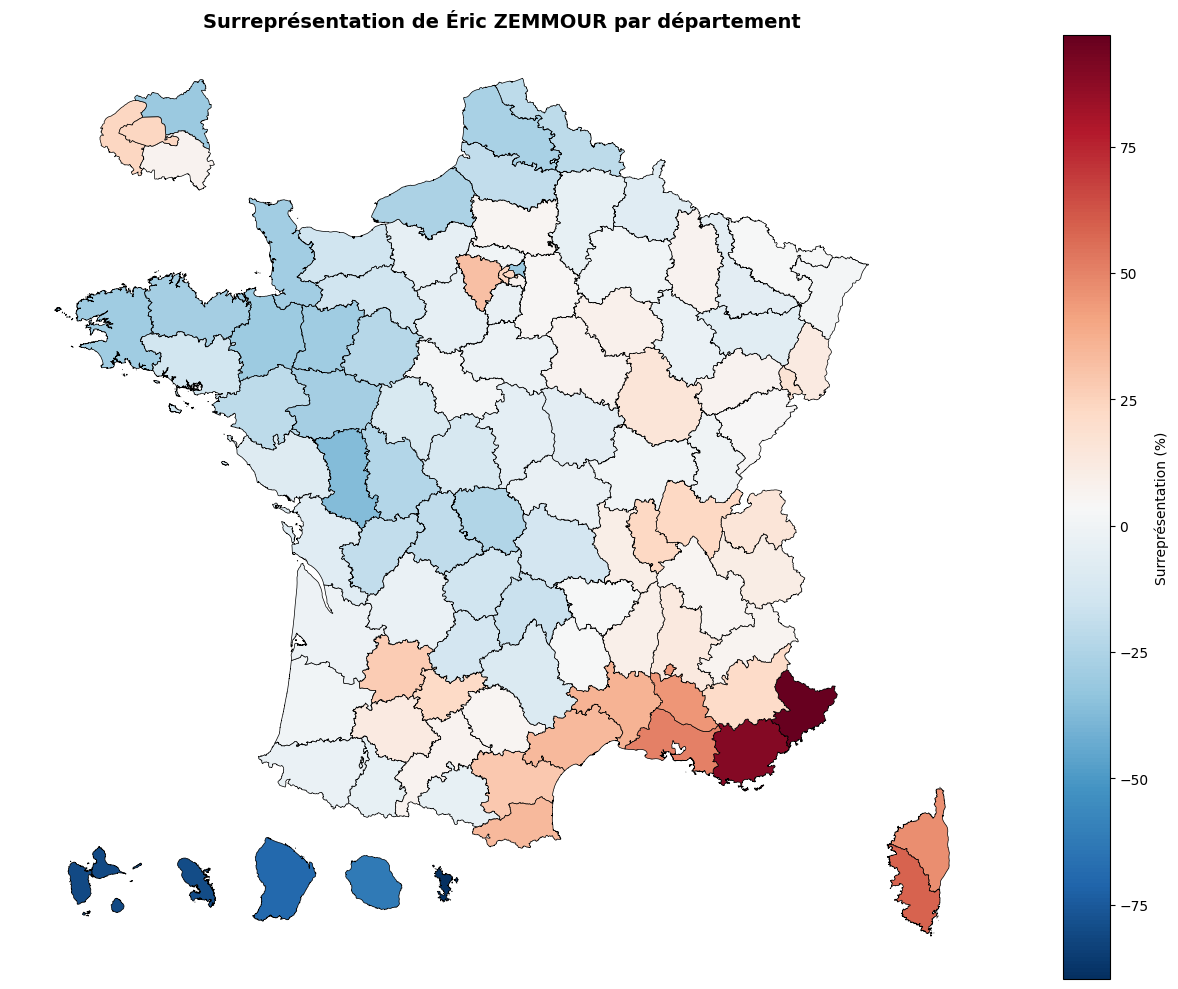

In [32]:
#test sur Éric Zemmour
zemmour_data = get_candidate_data('Éric ZEMMOUR', score_departements)
zemmour_map = gdf_departments.merge(
    zemmour_data,
    left_on='code',
    right_on='code_departement',
    how='left'
)
fig, ax = plt.subplots(figsize=(14, 10))
zemmour_map.plot(
    column='surrepresentation',
    ax=ax,
    legend=True,
    cmap='RdBu_r',
    edgecolor='black',
    linewidth=0.5,
    legend_kwds={'label': 'Surreprésentation (%)', 'orientation': 'vertical'}
)
ax.set_title('Surreprésentation de Éric ZEMMOUR par département', fontsize=14, fontweight='bold')
ax.axis('off')
plt.tight_layout()
plt.show()